Setup and Configuration

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

def run_diffusion(G, initial_seeds, threshold):
    """
    Simulates the diffusion process.
    Nodes in 'active' state are 1, 'inactive' are 0.
    """
    active_nodes = set(initial_seeds)
    newly_active = set(initial_seeds)

    history = [set(active_nodes)]

    while newly_active:
        newly_active = set()
        for node in G.nodes():
            if node not in active_nodes:
                neighbors = list(G.neighbors(node))
                if len(neighbors) > 0:
                    active_neighbors = [n for n in neighbors if n in active_nodes]
                    # The threshold logic: Fraction of active neighbors
                    if len(active_neighbors) / len(neighbors) >= threshold:
                        newly_active.add(node)

        if not newly_active:
            break

        active_nodes.update(newly_active)
        history.append(set(active_nodes))

    return history

def plot_network(G, active_nodes, title, pos):
    colors = ['#FF4B4B' if n in active_nodes else '#1C83E1' for n in G.nodes()]
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500, edge_color='#CBD5E0')
    plt.title(title)
    plt.show()

Case 1: Increasing the Payoff (Lowering Threshold)

Low Payoff Diffusion reached 2 nodes.
High Payoff Diffusion reached 25 nodes.


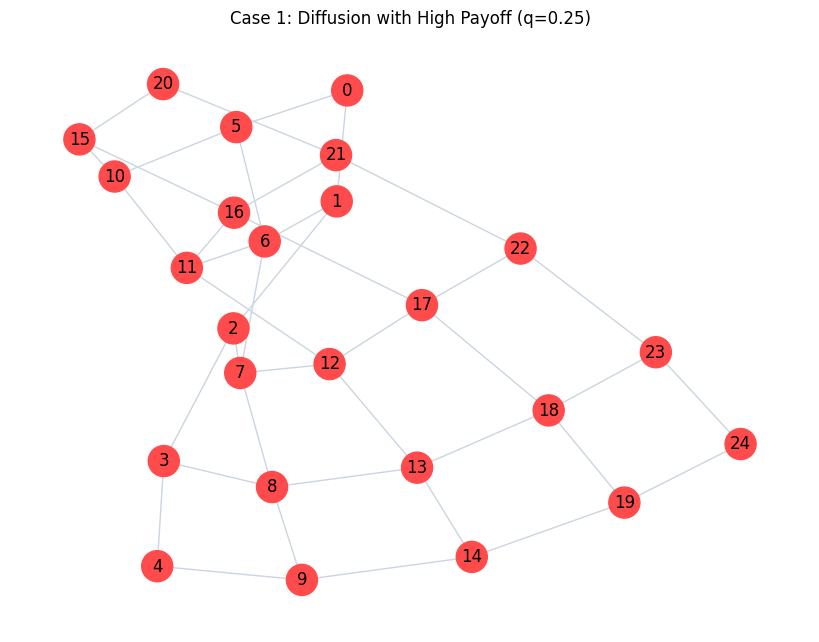

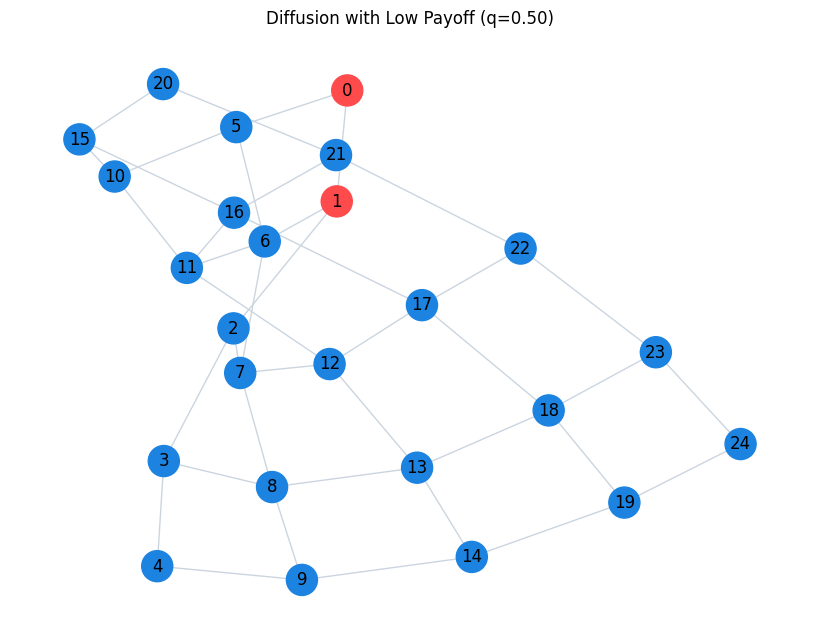

In [18]:
G_grid = nx.grid_2d_graph(5, 5)
G_grid = nx.convert_node_labels_to_integers(G_grid)
pos_grid = nx.spring_layout(G_grid, seed=42)
seeds = [0, 1]

# High Threshold (Low Payoff)
hist_low = run_diffusion(G_grid, seeds, threshold=0.5)
# Low Threshold (High Payoff)
hist_high = run_diffusion(G_grid, seeds, threshold=0.25)

print(f"Low Payoff Diffusion reached {len(hist_low[-1])} nodes.")
print(f"High Payoff Diffusion reached {len(hist_high[-1])} nodes.")

plot_network(G_grid, hist_high[-1], "Case 1: Diffusion with High Payoff (q=0.25)", pos_grid)
plot_network(G_grid, hist_low[-1], "Diffusion with Low Payoff (q=0.50)", pos_grid)

Case 2: Impact of Key People (Influence Maximization)

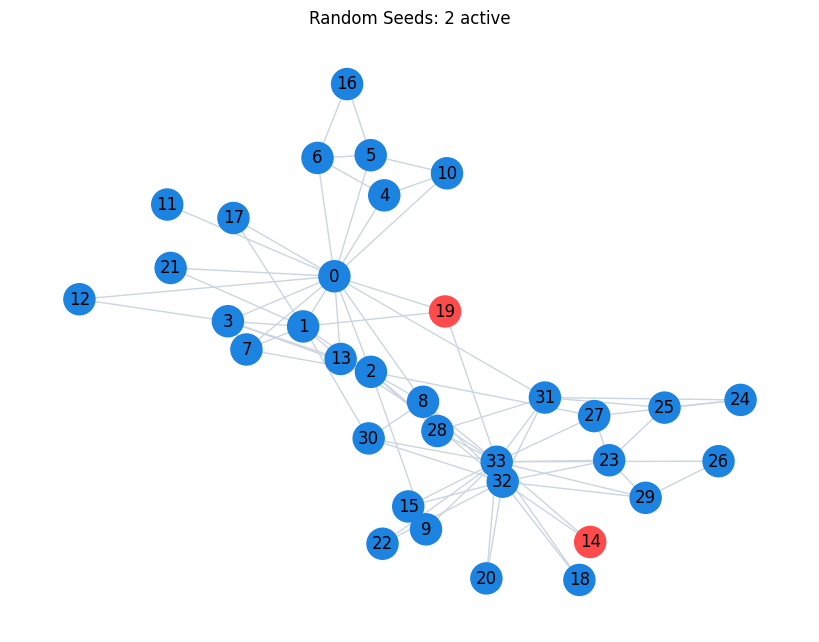

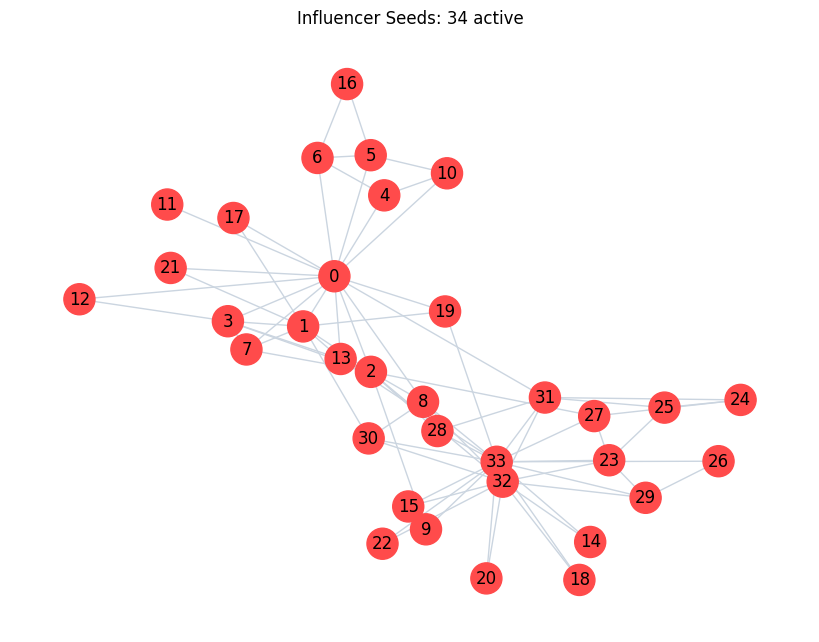

In [13]:
G_fb = nx.karate_club_graph()
pos_fb = nx.spring_layout(G_fb, seed=42)

# Strategic: Pick top 2 highest degree nodes
influencers = sorted(G_fb.degree, key=lambda x: x[1], reverse=True)[:2]
seed_influencers = [n[0] for n in influencers]

# Random: Pick 2 random nodes
seed_random = random.sample(list(G_fb.nodes()), 2)

res_inf = run_diffusion(G_fb, seed_influencers, threshold=0.3)
res_rand = run_diffusion(G_fb, seed_random, threshold=0.3)


plot_network(G_fb, res_rand[-1], f"Random Seeds: {len(res_rand[-1])} active", pos_fb)
plot_network(G_fb, res_inf[-1], f"Influencer Seeds: {len(res_inf[-1])} active", pos_fb)

Case 3: Impact of Communities on Cascades

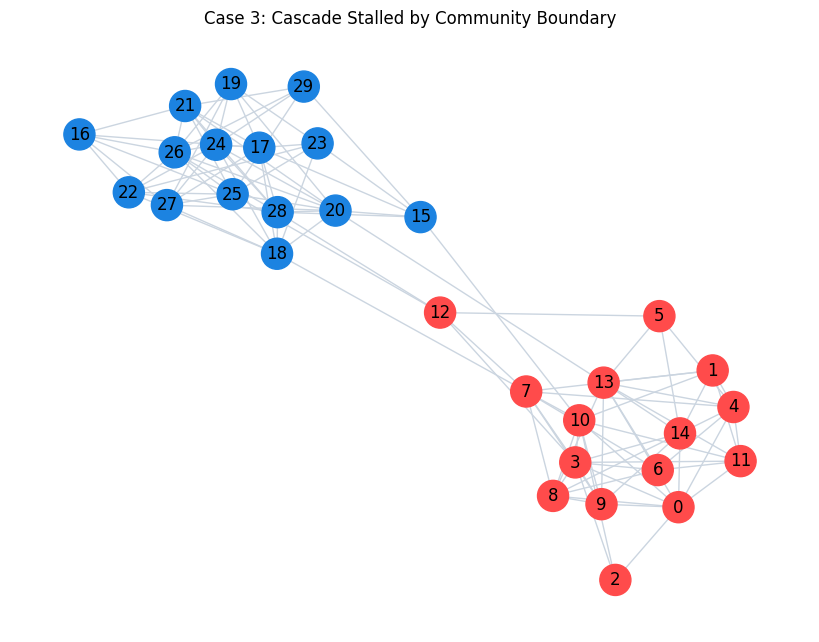

In [16]:
# Create two communities of 15 nodes each
sizes = [15, 15]
probs = [[0.5, 0.02], [0.02, 0.5]] # High internal density, low external
G_comm = nx.stochastic_block_model(sizes, probs, seed=42)
pos_comm = nx.spring_layout(G_comm)

# Start cascade in Community A
seeds_comm = [0, 1, 2]
hist_comm = run_diffusion(G_comm, seeds_comm, threshold=0.3)

plot_network(G_comm, hist_comm[-1], "Case 3: Cascade Stalled by Community Boundary", pos_comm)

Case 4: Cascades and Clusters (The "Density" Obstacle)

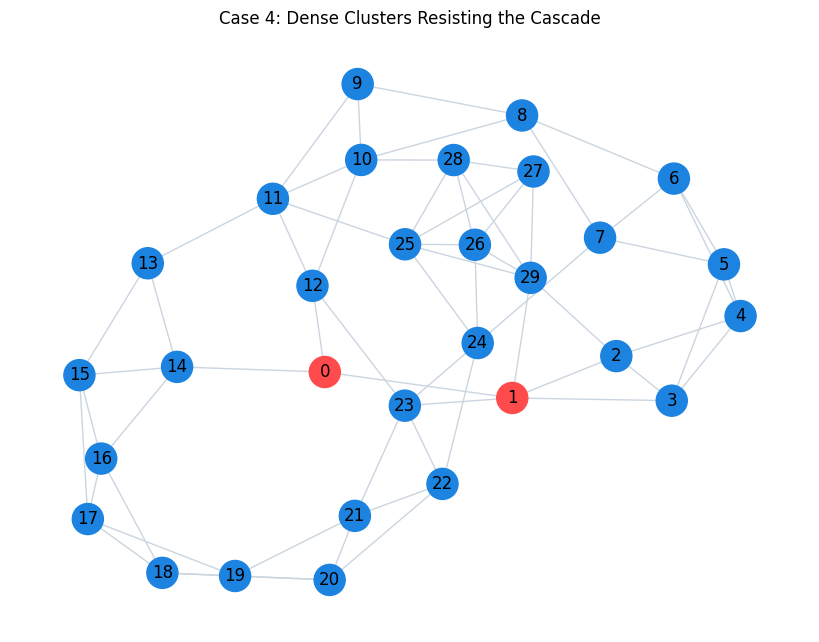

In [5]:
G_cluster = nx.connected_watts_strogatz_graph(30, 4, 0.1)
# Manually add a "Clique" (dense cluster) that is hard to penetrate
clique = list(range(25, 30))
for u in clique:
    for v in clique:
        if u != v: G_cluster.add_edge(u, v)

pos_cl = nx.kamada_kawai_layout(G_cluster)
seeds_cl = [0, 1] # Start far from the clique

# Use a threshold that the cluster can resist
hist_cl = run_diffusion(G_cluster, seeds_cl, threshold=0.4)

plot_network(G_cluster, hist_cl[-1], "Case 4: Dense Clusters Resisting the Cascade", pos_cl)